# COMp Model 5



# LCG

Is based on the recurrence formula $X_{n+1} = (aX^n + c) $ mod $m$, Given some $a$ multiplier, $c$ increment, $m$ modulus and the seed $X_0$. 

ALlgorithm:

* Start with seed $X_0$ 
* Compute $X_1 = (aX_0 + c)$ mod $m$
* Repeat for as many $n$

to normalize divide all by $m$ ofcourse.



## Part (a)



In [554]:
import numpy as np
def my_lcg(n, seed, a, c, m):
    x = seed % m
    seq = []

    for _ in range(n):
        seq.append(x / m)
        x = (a * x + c) % m

    return seq


## Part(b)

#### Here is the choice of parameters for The Bad Generator and The ”Standard” Generator (MINSTD) using Linear COngruential Generators for the notebook

In [555]:
N = 2000
seed = 1                    


bad   = my_lcg(N, seed, a=1229, c=1,   m=2048)               
minstd = my_lcg(N, seed, a=16807, c=0,   m=2**31 - 1)  
 


## part(c)

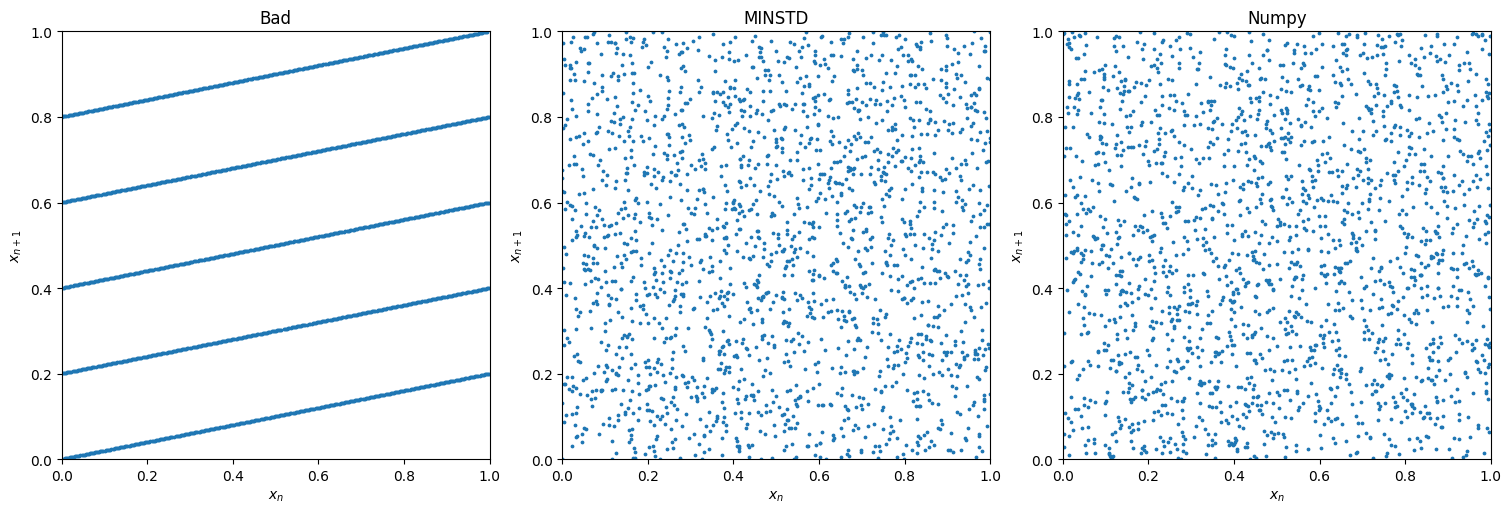

In [556]:
import matplotlib.pyplot as plt

def sc(data, title, ax=None):
    if ax is None:                 
        ax = plt.gca()

    ax.scatter(data[:-1], data[1:], s=3)
    ax.set_xlabel(r'$x_n$')
    ax.set_ylabel(r'$x_{n+1}$')
    ax.set_title(title)
    ax.set_aspect('equal')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)

sc(bad,    "Bad", axes[0])
sc(minstd, "MINSTD", axes[1])
sc(np.random.uniform(0.0, 1.0, N)  ,  "Numpy", axes[2] )

plt.show()


The bad generator plot can be predicted which can be because of the short period value ($m$ too small). This would lead to incorrect simulation of gas. MINSTD nor NUMPY show this. 



### Observations:

A set of straight, parallel lines is seen for the bad generator. Every point satisfies a linear congruence. 

# Deterministic Chaos

The logistic map is a chaotic map defined by:

$$ f_\lambda : [0,1] \to [0,1]$$
$$ f_\lambda (x) = \lambda x (1 - x)$$ 

for $\lambda \in [0, 4] \subset \mathbb{R}$



In [557]:
# logistic map

def logistic_map(x, r):
    return r * x * (1 - x)




## Part (d)

In [558]:
def logistic_random(N, seed, r):
    x = seed
    seq = []

    for _ in range(N):
        seq.append(x)
        x = logistic_map(x, r)

    return seq
# logistic_random(20, 0.3, 2.4)


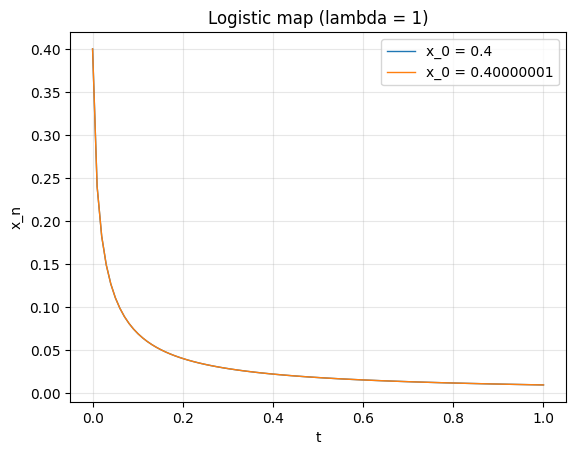

In [559]:

N = 100 
# Cases for (d)
caseA = logistic_random(N, 0.4, 1)
caseB = logistic_random(N, 0.40000001, 1)

time_list = np.linspace(0, 1, N)

plt.plot(time_list, caseA, label='x_0 = 0.4',        lw=1, color='tab:blue')
plt.plot(time_list, caseB, label='x_0 = 0.40000001', lw=1, color='tab:orange')
plt.xlabel('t')
plt.ylabel('x_n')
plt.title('Logistic map (lambda = 1)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()






We see that for the logistic map, we do not exhibit chaotic behaviour for values lower below the critical. This would not be a good random generator for values of lambda below 4 since that is when it exhbits dense distribution of orbits in the interval 0,1.

Even so, the values will be distributed in a non uniform way.
See below for any values of lamba.

#### Here is the choice of parameters for Logistic map for the notebook

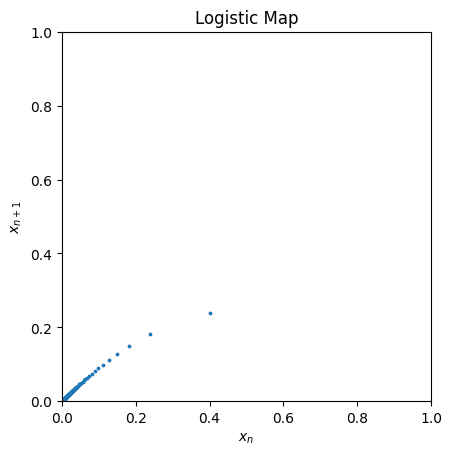

In [560]:
orbit = logistic_random(2000, 0.4, 1)

sc(orbit, "Logistic Map")

## Part (f)

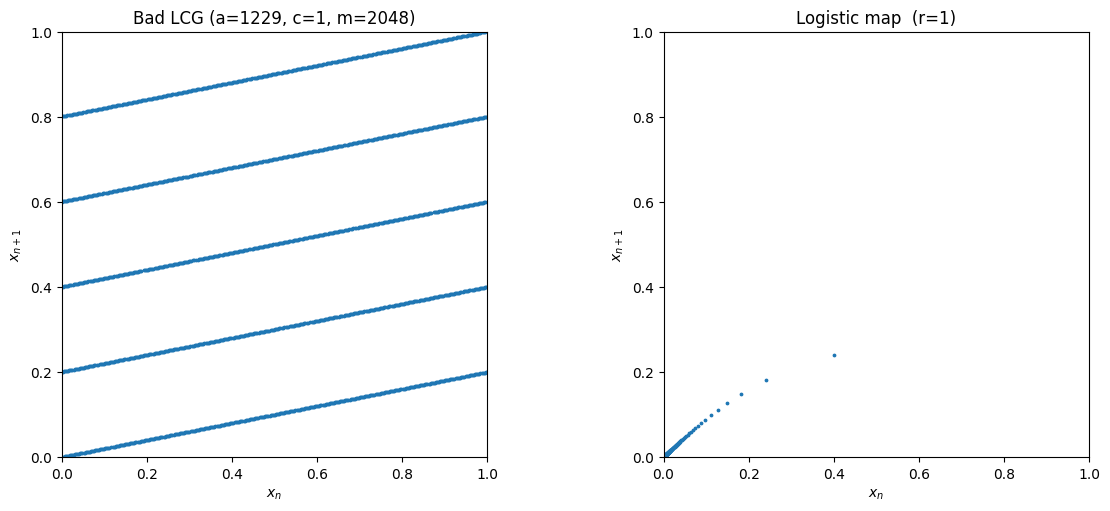

In [561]:



fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,5), constrained_layout=True)
sc(bad,   f'Bad LCG (a=1229, c=1, m=2048)', ax1)
sc( orbit,  f'Logistic map  (r=1)', ax2)

plt.show()

### Observations

Each point is mapped by a quadratic relation which leads to a parabola plot for chaotic values of lambda = 4.0. For lambda = 1, the interval gets contracted to the interval [0, 0.25]. 

Even when the time series looks noisy, the return‑map reveals that the underlying process is not truly random – it is confined to a deterministic manifold. This confinement can be bad for simulations because the sample space is not tested uniformly; This can bias methods like Monte‑Carlo, produce artificial correlations, etc.

## Part (g)

In [562]:
N = 500_000                        

uniform_seq = np.random.rand(N)      
logistic_seq = logistic_random(N, seed=0.4, r=1.0)
logistic_seq_2 = logistic_random(N, seed=0.4, r=4.0)


plotting 

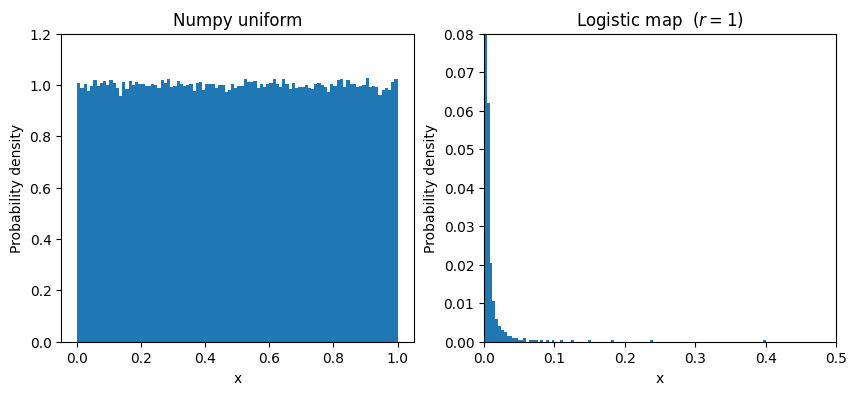

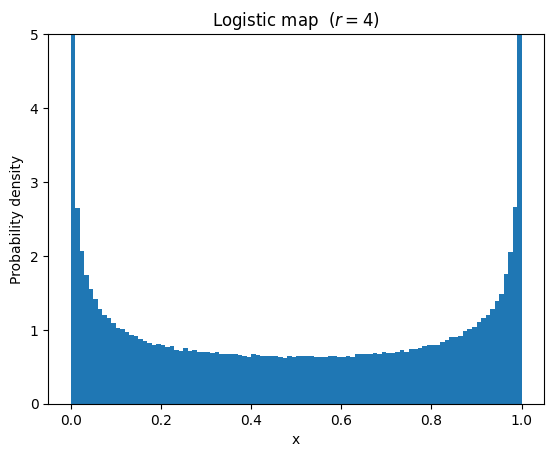

In [563]:
plt.figure(figsize=(10,4))

#numpy random uniform
plt.subplot(1,2,1)
plt.hist(uniform_seq, bins=100, density=True, edgecolor='none')
plt.title('Numpy uniform')
plt.xlabel('x')
plt.ylabel('Probability density')
plt.ylim(0, 1.2)                    

# logistic map for r = 1
plt.subplot(1,2,2)
plt.hist(logistic_seq, bins=100, density=True, edgecolor='none')
plt.title(r'Logistic map  ($r=1$)')
plt.xlabel('x')
plt.xlim(0,0.5)
plt.ylabel('Probability density')
plt.ylim(0, 0.08)                        
plt.show()

# logistic map for r = 4

plt.hist(logistic_seq_2, bins=100, density=True, edgecolor='none')
plt.title(r'Logistic map  ($r=4$)')
plt.xlabel('x')
plt.ylabel('Probability density')
plt.ylim(0, 5)                        
plt.show()


# Observations

We can see that the histogram plot is not uniform for the logistic map, in both cases for the value of lambda. The histogram of the logistic‑map sequence with  r=1 is strongly peaked at 0, zero for 
$x > 0.25$, and closely matches a (degenerate) Beta distribution. Thus the logistic map does not produce the uniform distribution required for a good pseudo‑random number generator. For r = 4 it produces a distribution densely concentrated at ${0,1}$ and does dstribute evenly.

